In [3]:
import numpy as np
from glob import glob
from ultralytics import YOLO
from yaml import safe_load
import matplotlib.pyplot as plt
import albumentations as A
import cv2
import warnings as warn
import os
import torch
warn.simplefilter('ignore')

In [4]:
DS_PATH= r'..\..\..\..\World Of Datasets\Un-Structured Datasets\Object Detection\Drones Detection Dataset\drone_dataset'
DATA_YAML_PATH = os.path.join(DS_PATH,'data.yaml') 

with open(DATA_YAML_PATH, 'r', encoding='utf-8') as file:
    yaml_data = safe_load(file)
yaml_data

{'names': ['drone'],
 'nc': 1,
 'train': '\\train\\images',
 'val': '\\valid\\images'}

In [5]:
new_train_path = os.path.join(DS_PATH, 'train', 'images')
new_val_path = os.path.join(DS_PATH, 'valid', 'images')

yaml_data['train'] = new_train_path
yaml_data['val'] = new_val_path

yaml_data

{'names': ['drone'],
 'nc': 1,
 'train': '..\\..\\..\\..\\World Of Datasets\\Un-Structured Datasets\\Object Detection\\Drones Detection Dataset\\drone_dataset\\train\\images',
 'val': '..\\..\\..\\..\\World Of Datasets\\Un-Structured Datasets\\Object Detection\\Drones Detection Dataset\\drone_dataset\\valid\\images'}

In [6]:
CONF= 0.40

EPOCHS = 30
IMG_SIZE = 380
BATCH_SIZE = 32
OPTIMIZER = 'adam'
LR0 = 1e-3
PATIENCE = 5
PLOTS = True
SAVE_WEIGHTS = True
NAME = 'Drones_Detected_Results'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_OF_WORKERS = 0
TRANSFORMS = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),

                A.OneOf([
                    A.GaussianBlur(blur_limit=3, p=1.0),
                    A.MotionBlur(blur_limit=5, p=1.0),
                ], p=0.3),
                
                A.CoarseDropout(
                    num_holes_range=(1, 1),
                    hole_height_range=(80, 130),
                    hole_width_range=(80, 130),
                    fill="random",
                    p=0.4
                ),

                A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),

                A.Rotate(limit=30, p=0.5),
                A.Affine(shear=(-10, 10), p=0.3),

                A.RandomShadow(p=0.2),
                A.ImageCompression(quality_range=(70, 100), p=0.2),
                A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
            ])


In [7]:
def show_all_shapes(path):

    imgs_items = os.listdir(path)
    all_shapes = []
    for img in imgs_items:
        img_shape = plt.imread(os.path.join(path,img)).shape

        all_shapes.append(img_shape)

    return set(all_shapes)

In [115]:
train_img_shapes = show_all_shapes(yaml_data['train'])
print('All Shapes Length is ',len(train_img_shapes))
print('All Shapes: ',train_img_shapes)

All Shapes Length is  521
All Shapes:  {(1800, 3200, 3), (366, 515, 3), (330, 1551, 3), (438, 1030, 3), (1000, 1370, 4), (378, 500, 3), (373, 650, 3), (510, 680, 3), (301, 592, 3), (480, 417, 3), (1269, 1932, 3), (599, 500, 3), (267, 360, 4), (166, 250, 4), (576, 1121, 4), (413, 620, 3), (516, 706, 3), (309, 832, 3), (361, 361, 3), (800, 1200, 4), (643, 1060, 4), (794, 794, 3), (1037, 1383, 3), (209, 372, 3), (599, 987, 4), (613, 613, 3), (1024, 683, 3), (675, 954, 3), (517, 940, 3), (380, 570, 3), (282, 500, 3), (1080, 1080, 3), (500, 1229, 3), (316, 640, 4), (344, 612, 3), (1022, 3266, 3), (339, 600, 3), (360, 640, 3), (361, 525, 3), (542, 722, 3), (768, 1024, 3), (1080, 1920, 3), (343, 609, 3), (750, 500, 3), (250, 300, 3), (366, 750, 3), (1316, 2520, 3), (869, 1074, 3), (334, 500, 3), (347, 616, 3), (338, 600, 4), (592, 768, 4), (1443, 1500, 3), (389, 516, 3), (368, 640, 4), (257, 672, 3), (362, 579, 3), (620, 797, 3), (837, 1240, 3), (433, 770, 3), (450, 800, 3), (2448, 2448, 3), 

In [116]:
val_img_shapes = show_all_shapes(yaml_data['val'])
print('All Shapes Length is ',len(val_img_shapes))
print('All Shapes: ',val_img_shapes)

All Shapes Length is  155
All Shapes:  {(1334, 2000, 3), (557, 992, 3), (511, 800, 3), (648, 864, 3), (181, 279, 3), (237, 355, 3), (394, 860, 3), (533, 800, 3), (683, 1024, 3), (736, 960, 3), (853, 1280, 3), (350, 1400, 3), (550, 900, 3), (400, 900, 3), (267, 400, 3), (466, 466, 3), (1001, 1500, 3), (600, 600, 3), (3648, 5472, 3), (271, 500, 3), (236, 236, 3), (1800, 2400, 3), (844, 1500, 3), (585, 1170, 3), (325, 710, 3), (500, 899, 3), (380, 570, 3), (1000, 1600, 3), (1080, 1080, 3), (479, 852, 3), (365, 648, 3), (1035, 1380, 3), (550, 824, 3), (290, 870, 3), (500, 1440, 3), (456, 810, 3), (360, 640, 3), (684, 912, 3), (501, 750, 3), (1500, 1500, 3), (1080, 1920, 3), (630, 1500, 3), (580, 580, 3), (1000, 1500, 3), (425, 299, 3), (450, 660, 3), (2500, 2500, 3), (480, 800, 3), (500, 825, 3), (350, 350, 3), (3750, 5625, 3), (500, 750, 3), (1600, 2400, 3), (1000, 1000, 3), (276, 628, 3), (512, 512, 3), (671, 994, 3), (248, 500, 3), (1066, 1600, 3), (2916, 5184, 3), (1801, 2400, 3), (200

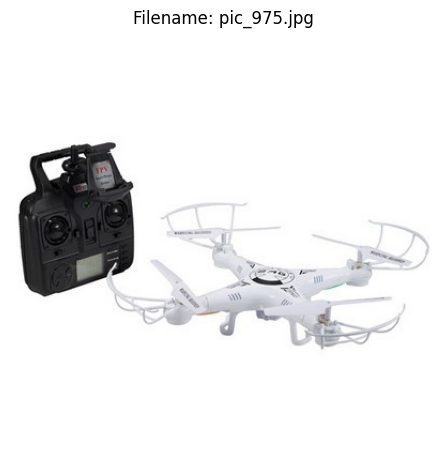

In [8]:
def show_rand_img(path):
    imgs_items = os.listdir(path)
    rand_img = np.random.choice(imgs_items)
    plt.imshow(plt.imread(os.path.join(path,rand_img)))
    plt.title(f"Filename: {rand_img}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
show_rand_img(yaml_data['train'])

In [9]:
test = 'train\\'
test.replace('train','labels')

'labels\\'

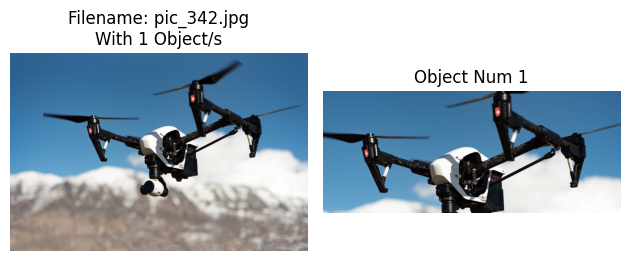

In [94]:
def show_objects_by_coordinates(path):
    imgs_items = os.listdir(path)
    rand_img = np.random.choice(imgs_items)
    filename = rand_img.split('.')
    img = plt.imread(os.path.join(path,rand_img))
    h,w = img.shape[:2]

    with open(os.path.join(path.replace('images' , 'labels'),filename[0]+'.txt')) as f:
        coordinates_data = f.readlines()

    fig, ax = plt.subplots(1, len(coordinates_data) + 1)

    # Orginal Image
    ax[0].imshow(img)
    ax[0].set_title(f"Filename: {rand_img}\nWith {len(coordinates_data)} Object/s")
    ax[0].axis('off')

    # Objects in image
    for i,coord_item in enumerate(coordinates_data):
        cls, xc, yc, bw, bh = map(float, coord_item.split())

        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        # print(cls,x1,y1,x2,y2)
        # print(cls,xc,yc,bw,bh)
        ax[i+1].imshow(img[y1:y2:,x1:x2])
        ax[i+1].set_title(f"Object Num {i+1}")
        ax[i+1].axis('off')

    plt.tight_layout()
    plt.show()
show_objects_by_coordinates(yaml_data['train'])

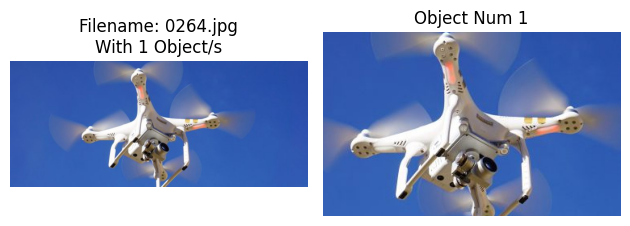

In [106]:
show_objects_by_coordinates(yaml_data['val'])

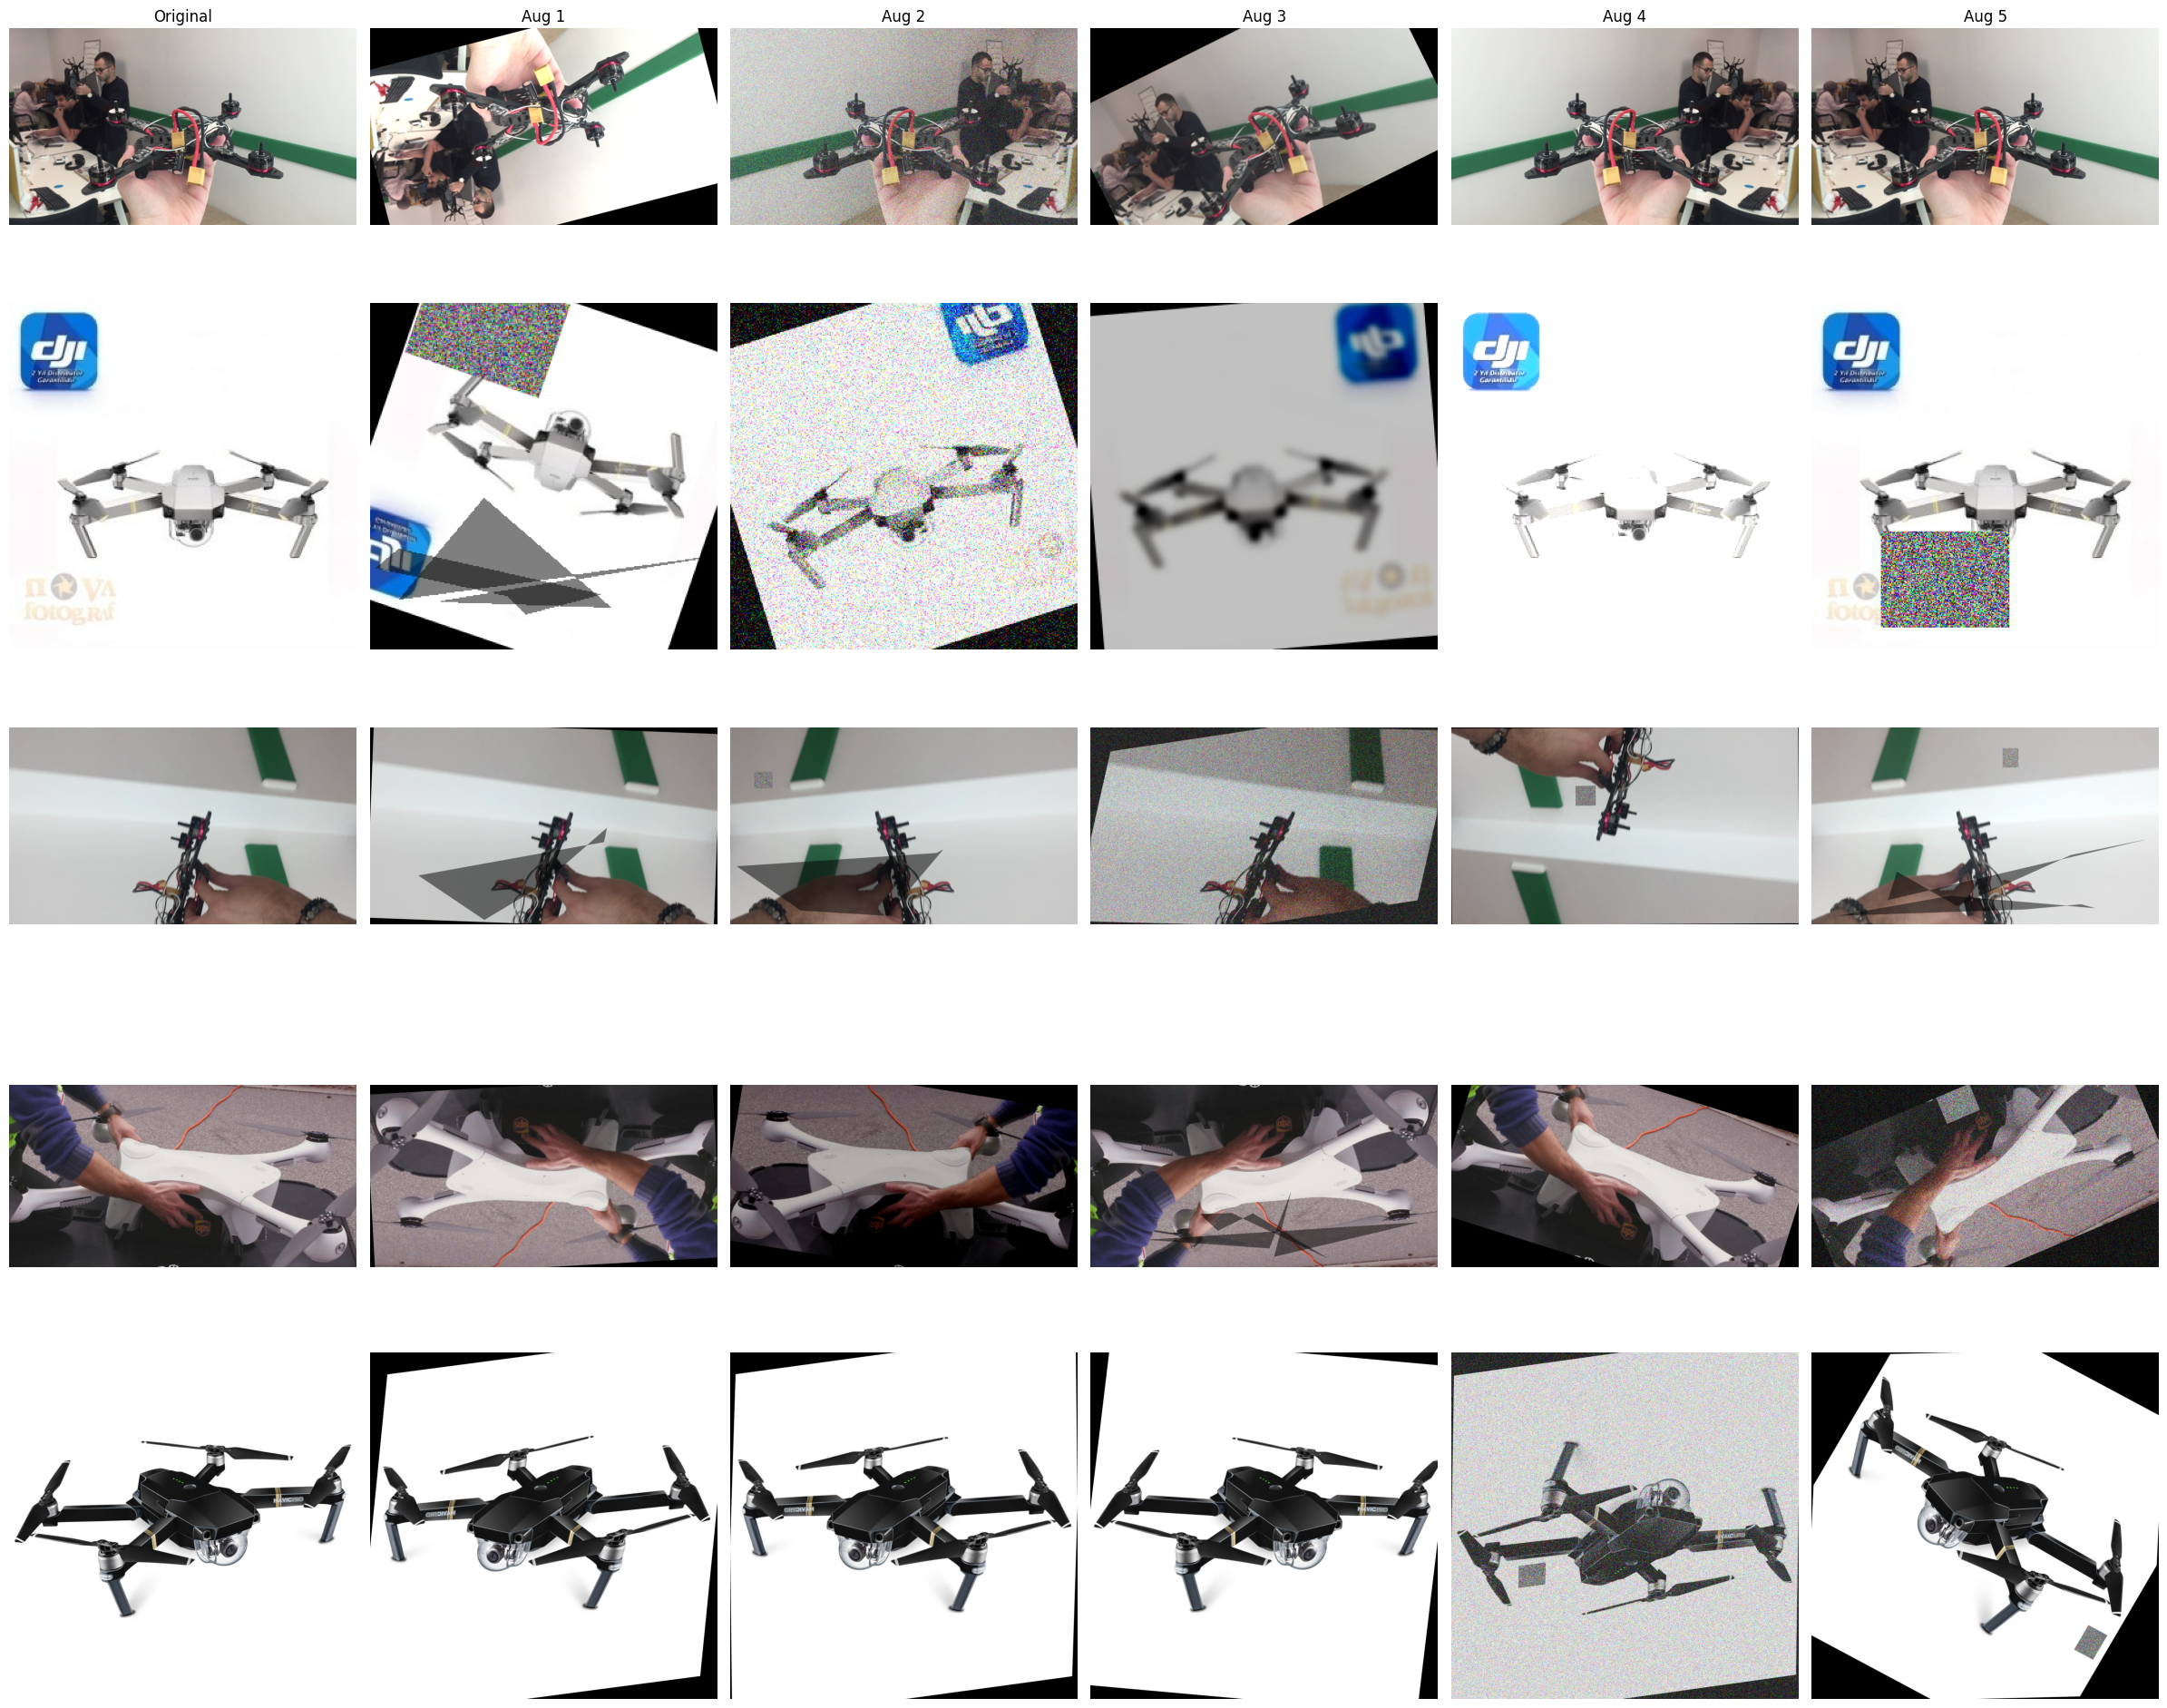

In [22]:
def show_augmentations(path, transforms, rows=5,cols=5):
    imgs_items = os.listdir(path)

    fig, axes = plt.subplots(rows, cols + 1, figsize=(4 * (cols + 1), 4 * rows))

    for row in range(rows):
        rand_img = np.random.choice(imgs_items)
        image = cv2.imread(os.path.join(path,rand_img),cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        axes[row, 0].imshow(image)
        axes[row, 0].set_title("Original" if row == 0 else "")
        axes[row, 0].axis("off")

        for col in range(1, cols + 1):
            augmented = transforms(image=image)["image"]
            axes[row, col].imshow(augmented)
            axes[row, col].set_title(f"Aug {col}" if row == 0 else "")
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

show_augmentations(yaml_data['train'], TRANSFORMS)